# Риск и распределение инвестиций в стартапы: расчёт объёма инвестиций

---

# Цель:
- Написать модель машинного обучения для:
    - рассчёта оптимального объёма инвестиций в стартап;
    - выявление признаков, влияющих на объём инвестиций;
    - сохранение модели для дальнейшего использования (расчёт объёма инвестиций).

In [1]:
import os
import numpy as np
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
plt.rcParams['figure.figsize'] = (8, 7)
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/startup_investment_dataset+rejected_status.csv')

In [3]:
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,market_size_estimate,investment_amount,is_rejected
0,Pre-Seed,ClimateTech,US,1.381327e+06,7.223187e+06,9,3,0.000000,6.039942e+06,0.000000e+00,1
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,96087.461835,6.886030e+07,7.203092e+06,0
2,Pre-Seed,HealthTech,LATAM,1.306439e+06,1.022702e+07,5,3,0.000000,1.896208e+07,0.000000e+00,1
3,Idea,E-commerce,US,8.840830e+05,4.531614e+06,3,2,0.000000,7.717272e+06,0.000000e+00,1
4,Series B,E-commerce,US,1.608484e+07,5.189190e+07,10,7,133652.729965,1.415670e+07,1.672645e+07,0


In [4]:
df = df[df['is_rejected'] == 0].drop(columns=['is_rejected', 'market_size_estimate'])
print(f'Общая длина: {len(df)} стартапов')
df.head()

Общая длина: 1948 стартапов


,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06
4,Series B,E-commerce,US,1.608484e+07,5.189190e+07,10,7,1.336527e+05,1.672645e+07
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06


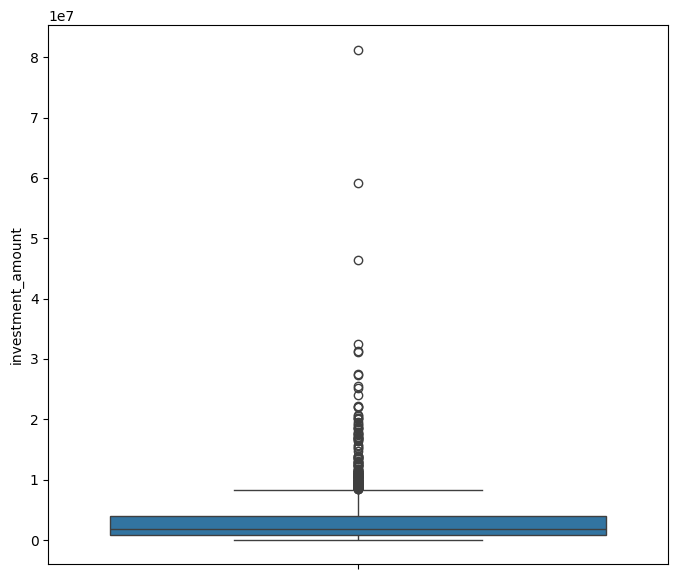

In [5]:
sns.boxplot(y=df['investment_amount'])
plt.show()

In [6]:
# Избавление от выбросов
q_low = df['investment_amount'].quantile(0.01)
q_high = df['investment_amount'].quantile(0.95)

df = df[(df['investment_amount'] >= q_low) & (df['investment_amount'] <= q_high)]

print(f'Отобрано {len(df)} стартапов с объёмом инвестиций от ${int(q_low):,} до ${int(q_high):,}.')

Отобрано 1830 стартапов с объёмом инвестиций от $137,361 до $10,043,519.


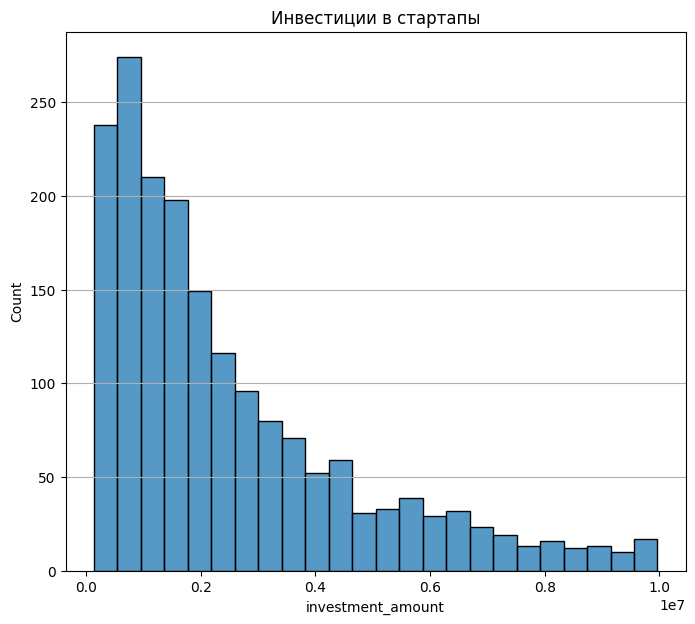

In [7]:
sns.histplot(data=df, x='investment_amount')
plt.title('Инвестиции в стартапы')
plt.grid(axis='y')
plt.show()

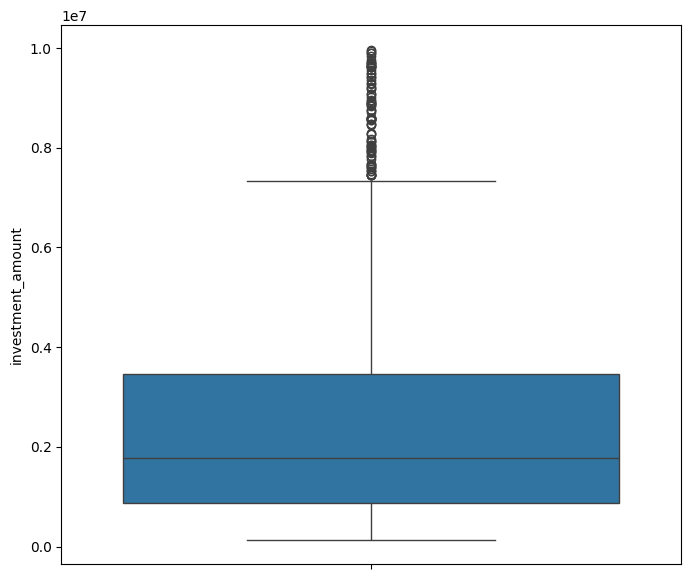

In [8]:
sns.boxplot(y=df['investment_amount'])
plt.show()

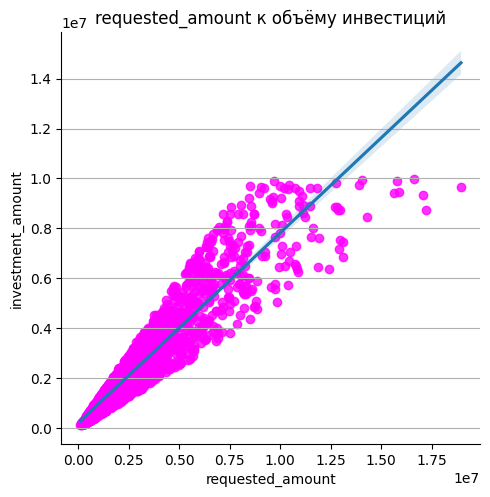

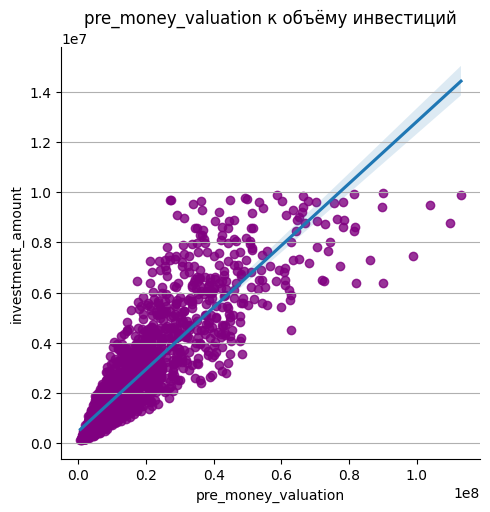

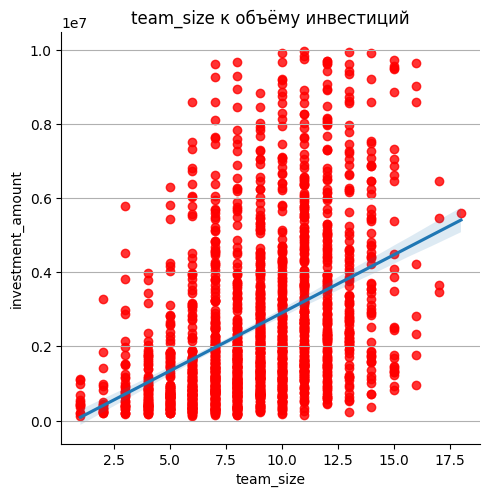

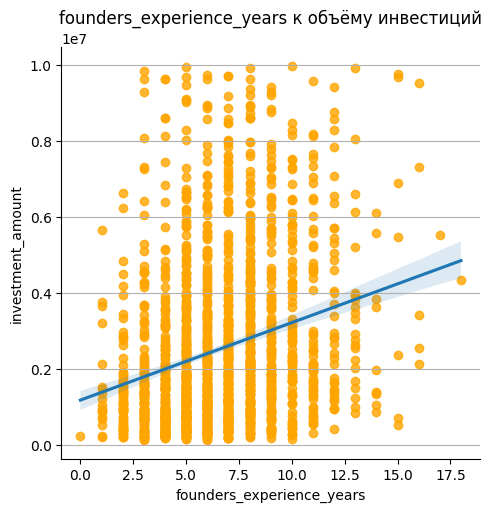

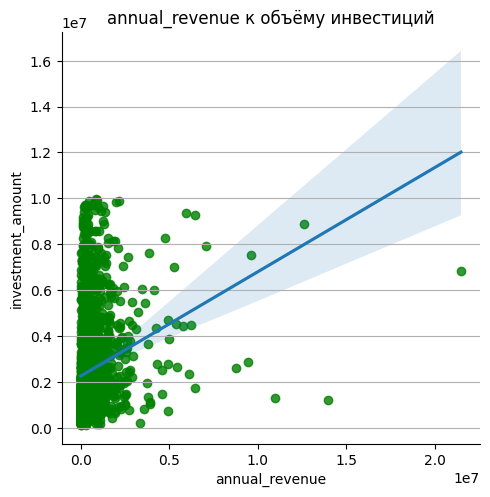

In [9]:
color_map = {
    'requested_amount': 'magenta',
    'team_size': 'red',
    'annual_revenue': 'green',
    'pre_money_valuation': 'purple',
    'founders_experience_years': 'orange'
}

for feature in df.select_dtypes(include=['int64', 'float64']).columns:
    if feature != 'investment_amount':
        sns.lmplot(
            data=df,
            x=feature,
            y='investment_amount',
            scatter_kws={'color': color_map.get(feature, 'gray')},
        )
        plt.grid(axis='y')
        plt.title(f'{feature} к объёму инвестиций')
        plt.show()

# Моделирование

In [10]:
import mlflow

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## Feature engineering

Добавление новых признаков для лучшего обучения модели:

- Добавление отношений денежных признаков;
- Добавление производных признаков от команды;
- Бизнес-признаки;
- Логарифмирование денежных и остальных числовых признаков;

In [11]:
def create_additional_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    eps = 1

    # --- Отношения денежных признаков ---
    df['requested_to_valuation'] = (df['requested_amount'] / (df['pre_money_valuation'] + eps))
    df['revenue_to_valuation'] = (df['annual_revenue'] / (df['pre_money_valuation'] + eps))
    df['revenue_per_employee'] = (df['annual_revenue'] / (df['team_size'] + eps))

    # --- Команда ---
    df['experience_per_member'] = (df['founders_experience_years'] / (df['team_size'] + eps))
    df['team_maturity'] = (df['team_size'] * df['founders_experience_years'])

    # --- Бизнес-флаги ---
    df['early_stage'] = (df['startup_stage'].isin(['Idea', 'Pre-Seed']).astype(int))
    df['is_us_market'] = ((df['region'] == 'US').astype(int))

    # --- Логарифмы денежных признаков ---

    numeric_features = df.select_dtypes(include=['int64', 'float64'])

    for col in numeric_features:
        if col in df.columns:
            df[f'{col}_log'] = np.log1p(df[col])

    # Очистка проблем после деления
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df

In [12]:
df = create_additional_features(df)
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,...,founders_experience_years_log,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06,0.255296,...,2.197225,11.473025,15.790021,0.227371,0.003146,8.834102,0.451985,4.653960,0.0,0.693147
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06,0.138034,...,1.386294,12.078277,14.284384,0.129303,0.009700,9.881098,0.287682,3.218876,0.0,0.000000
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06,0.235490,...,1.791759,14.014015,15.364535,0.211468,0.037755,11.529118,0.348307,4.025352,0.0,0.693147
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06,0.132729,...,1.098612,11.749230,14.828978,0.124630,0.005318,9.446716,0.182322,2.944439,0.0,0.693147
9,Seed,FinTech,US,2.722484e+06,1.256703e+07,8,8,3.605893e+05,1.459347e+06,0.216637,...,2.197225,12.795498,14.193501,0.196091,0.028289,10.598295,0.635989,4.174387,0.0,0.693147


In [13]:
# Логарифмирование целевой переменной
df['investment_amount_log'] = np.log1p(df['investment_amount'])

target = 'investment_amount_log'

## Разбиение и преобразование данных

In [14]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

In [15]:
target_remove_cols = ['investment_amount', 'investment_amount_log']

num_features = [c for c in num_features if c not in target_remove_cols]

In [16]:
X = df.drop(columns=['investment_amount', 'investment_amount_log'])
y = df[target]

print(f'> Featrues {X.shape}: \n{X.columns.tolist()}\n')
print(f'> Target {y.shape}: \n{target}')

> Featrues (1830, 27): 
['startup_stage', 'industry', 'region', 'requested_amount', 'pre_money_valuation', 'team_size', 'founders_experience_years', 'annual_revenue', 'requested_to_valuation', 'revenue_to_valuation', 'revenue_per_employee', 'experience_per_member', 'team_maturity', 'early_stage', 'is_us_market', 'requested_amount_log', 'pre_money_valuation_log', 'team_size_log', 'founders_experience_years_log', 'annual_revenue_log', 'requested_to_valuation_log', 'revenue_to_valuation_log', 'revenue_per_employee_log', 'experience_per_member_log', 'team_maturity_log', 'early_stage_log', 'is_us_market_log']

> Target (1830,): 
investment_amount_log


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

In [18]:
preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), num_features),
    ('encoder', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

# Кластеризация стартапов

- В распределении объёмов инвестиций наблюдается сильный скос вправо, что говорит о наличии отлично высоких объёмах, следовательно модель не сможет стабильно работать на всей выборке
- Кластеризация стартапов поможет разбить их на группы, на каждую из которых можно создать уникальную регрессионную модель.
- Идея кластеризации заключается в разделении стартапов на сегменты: __дешёвые__, __средние__ и ___дорогие__, при том __без использования целевой переменной__, поскольку кластер будет являться __прокси-признаком__, вызывающим:
    - Утечку данных;
    - Невозможность присвоить кластер при оценке новых стартапов.

В качестве признаков для сегментации используются:

- `requested_amount` — запрошенный объём инвестиций;
- `pre_money_valuation` — предварительная оценка стартапа;
- `annual_revenue` — существующая годовая выручка стартапа;
- `team_size` — количество сотрудников/участников;
- `founders_experience_years` — опыт сотрудников/участников.

In [19]:
cluster_features = [
    'requested_amount',
    'pre_money_valuation',
    'annual_revenue',
    'team_size',
    'founders_experience_years'
]

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(
    df[cluster_features]
)

df['cluster'] = clusters
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,...,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log,cluster
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06,0.255296,...,11.473025,15.790021,0.227371,0.003146,8.834102,0.451985,4.653960,0.0,0.693147,0
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06,0.138034,...,12.078277,14.284384,0.129303,0.009700,9.881098,0.287682,3.218876,0.0,0.000000,0
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06,0.235490,...,14.014015,15.364535,0.211468,0.037755,11.529118,0.348307,4.025352,0.0,0.693147,0
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06,0.132729,...,11.749230,14.828978,0.124630,0.005318,9.446716,0.182322,2.944439,0.0,0.693147,0
9,Seed,FinTech,US,2.722484e+06,1.256703e+07,8,8,3.605893e+05,1.459347e+06,0.216637,...,12.795498,14.193501,0.196091,0.028289,10.598295,0.635989,4.174387,0.0,0.693147,1


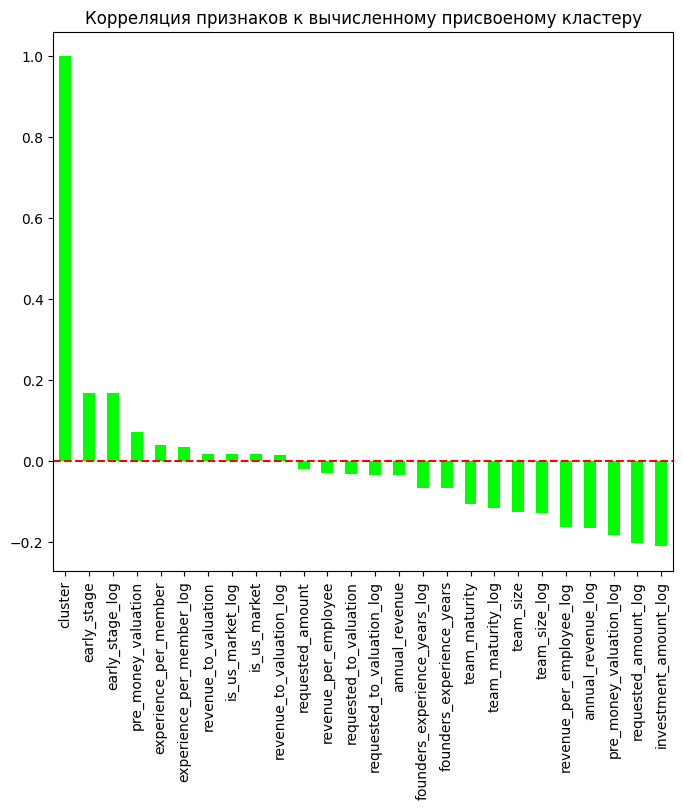

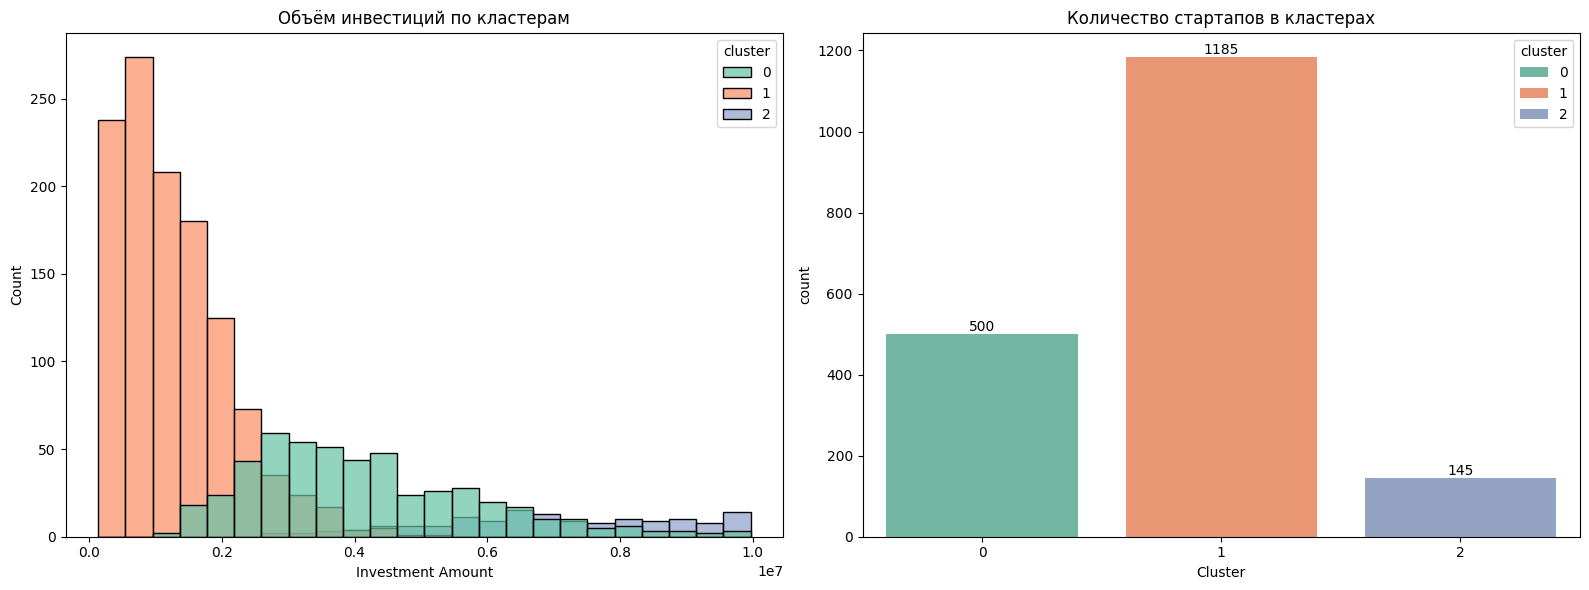

In [20]:
ax = (
    df.drop(columns=['investment_amount'])
        .corr(numeric_only=True)['cluster']
        .sort_values(ascending=False).plot(kind='bar', color='lime')
     )
plt.axhline(y=0, linestyle='--', c='red')
plt.title('Корреляция признаков к вычисленному присвоеному кластеру')
plt.show()

# ---------------------------------

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Clusters palette
palette = {
    0: "#66c2a5",
    1: "#fc8d62",
    2: "#8da0cb"
}

df_sorted = df.sort_values(by='investment_amount', ascending=True)

sns.histplot(data=df_sorted, x='investment_amount', hue='cluster', palette=palette, alpha=.7, ax=axes[0])
axes[0].set_title('Объём инвестиций по кластерам')
axes[0].set_xlabel('Investment Amount')

sns.countplot(data=df, x='cluster', hue='cluster', palette=palette, ax=axes[1])
# Подписи над столбцами
for container in axes[1].containers:
    axes[1].bar_label(container)
axes[1].set_title('Количество стартапов в кластерах')
axes[1].set_xlabel('Cluster')
plt.tight_layout()

plt.show()

In [23]:
### print('Процентное соотношение сегментов:\n', df['cluster'].value_counts(normalize=True).sort_index() * 100)

cluster_stats = df.groupby('cluster').mean(numeric_only=True).sort_values(by='requested_amount')
display(cluster_stats)

,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,revenue_to_valuation,revenue_per_employee,experience_per_member,...,founders_experience_years_log,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log
cluster,,,,,,,,,,,,,,,,,,,,,
1,1.518244e+06,7.675757e+06,7.883544,6.105485,3.701128e+05,1.283610e+06,0.204596,0.050315,37229.736339,0.755906,...,1.890297,7.641375,13.836396,0.184981,0.044528,6.270063,0.538390,3.723352,0.280768,0.308845
0,4.870734e+06,2.577044e+07,10.144000,7.222000,8.162073e+05,4.126508e+06,0.190482,0.033428,72766.831207,0.675418,...,2.045486,12.496947,15.149622,0.173430,0.031723,10.202036,0.502194,4.190862,0.030498,0.307757
2,9.011337e+06,5.635240e+07,10.910345,7.620690,1.187809e+06,6.999386e+06,0.161045,0.022497,101772.364696,0.661468,...,2.101105,13.222635,15.723200,0.148850,0.021469,10.785706,0.495819,4.335405,0.004780,0.339403


--- 

## Кластеризация стартапов

Для дополнительной сегментации стартапов была проведена кластеризация методом K-Means. Целью являлось выделение групп компаний со схожими финансовыми и организационными характеристиками для последующего использования в инвестиционном пайплайне.

### Использованные признаки

Для кластеризации использовались признаки, характеризующие масштаб и зрелость стартапа:

- `requested_amount`
- `pre_money_valuation`
- `annual_revenue`
- `team_size`
- `founders_experience_years`

Важно отметить, что целевые переменные:

- `investment_amount`

не использовались при обучении кластеризации, что исключает утечку данных (data leakage).

---

## Распределение стартапов по кластерам

| Кластер | Количество | Доля |
|----------|------------:|------:|
| 0 | 500 | 27.3% |
| 1 | 1185 | 64.8% |
| 2 | 145 | 7.9% |

Наибольшая часть стартапов относится к кластеру 1, в то время как кластер 2 содержит небольшое количество наиболее крупных компаний.

---

## Средние значения ключевых признаков

| Кластер | Requested Amount | Pre-money Valuation |
|----------|----------------:|--------------------:|
| 1 | 1.52M | 7.68M |
| 0 | 4.87M | 25.77M |
| 2 | 9.01M | 56.35M |

Наблюдается выраженная градация между сегментами:

```text
Cluster 1 → Cluster 0 → Cluster 2
малые → средние → крупные
```

Рост объёма запрашиваемых инвестиций сопровождается увеличением оценки стартапов, что выглядит реалистично и соответствует логике венчурного рынка.

---

## Интерпретация кластеров

### Cluster 1 — Emerging Startups

Наиболее массовый сегмент. Включает относительно небольшие компании с низким объёмом инвестиций и умеренной оценкой.

Характеристики:

- ранние стадии развития
- небольшие команды
- ограниченный объём ресурсов
- типичный рынок стартапов

---

### Cluster 0 — Growth Startups

Стартапы среднего масштаба.

Характеристики:

- более крупные команды
- более высокая оценка
- повышенные требования к инвестициям
- признаки стадии активного роста

---

### Cluster 2 — Large / High-capital Startups

Наиболее крупный и редкий сегмент.

Характеристики:

- высокий объём капитала
- высокая оценка
- зрелые команды
- повышенная инвестиционная стоимость

---

## Вывод

Кластеризация выявила устойчивую структуру стартапов без использования целевых признаков. Полученные группы отражают различия в масштабе и зрелости компаний и могут использоваться как дополнительный этап пайплайна.

Предполагаемое применение:

```text
Startup Features
        ↓
Cluster Prediction
        ↓
Specialized Regressor
        ↓
Investment Amount Prediction
```

Такой подход позволяет строить специализированные модели для разных сегментов рынка и потенциально снижать ошибку регрессии на крупных инвестиционных сделках.

# Обучение моделей машинного обучения

In [ ]:
MODELS = {
    'ridge': (
        Ridge(random_state=42),
        {
            'model__alpha': [0.1, 1.0, 10.0]
        }
    ),

    'lasso': (
        Lasso(random_state=42),
        {
            'model__alpha': [0.01, 0.1, 1.0]
        }
    ),

    'random_forest': (
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        {
            'model__n_estimators': [200, 500],
            'model__max_depth': [None, 10, 20]
        }
    ),

    'gboost': (
        GradientBoostingRegressor(
            random_state=42
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5]
        }
    ),

    'xgb': (
        XGBRegressor(
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 5, 7],
            'model__min_child_weight': [1, 5],
            'model__subsample': [0.7, 0.9],
            'model__colsample_bytree': [0.7, 0.9],
            'model__reg_alpha': [0, 0.1, 1],
            'model__reg_lambda': [1, 5]
        }
    ),

    'lgbm': (
        LGBMRegressor(
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [-1, 5, 10],
            'model__num_leaves': [31, 63],
            'model__min_child_samples': [20, 50],
            'model__subsample': [0.7, 0.9],
            'model__colsample_bytree': [0.7, 0.9]
        }
    )
}

MODELS.keys()

In [ ]:
trained_models = []

def train_models(X_train, X_test, y_train, y_test, preprocessor, report_dir="artifacts/reports/regression"):
    os.makedirs(report_dir, exist_ok=True)

    results = []

    for model_name, (model, param_grid) in MODELS.items():
        print("\n" + "=" * 60)
        print(f"MODEL: {model_name.upper()}")
        print("=" * 60)

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        with mlflow.start_run(run_name=model_name):
            mlflow.set_tag("task", "regression")
            mlflow.set_tag("model_name", model_name)

            print("GridSearchCV running...")

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring='neg_root_mean_squared_error',
                cv=5,
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_
            
            # Predictions
            y_pred_log = best_model.predict(X_test)

            y_pred = np.expm1(y_pred_log)
            y_true = np.expm1(y_test)

            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)
            mape = np.mean(np.abs((y_true-y_pred)/ y_true))

            print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.3f} | MAPE: {mape:.2%}")

            # Save model into list 
            trained_models.append(best_model)

            # MLflow
            mlflow.log_params(grid.best_params_)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("r2", r2)
            mlflow.log_metric("cv_rmse", abs(grid.best_score_))
            mlflow.sklearn.log_model(best_model, "model")
            
            # Report
            report_path = os.path.join(
                report_dir,
                f"{model_name}_report.txt"
            )

            with open(report_path, "w", encoding="utf-8") as f:
                f.write(f"MODEL: {model_name}\n")
                f.write(f"RMSE: {rmse:.2f}\n")
                f.write(f"MAE: {mae:.2f}\n")
                f.write(f"R2: {r2:.4f}\n\n")
                f.write("BEST PARAMS:\n")

                for k, v in grid.best_params_.items():
                    f.write(f"{k}: {v}\n")

            mlflow.log_artifact(report_path)

            results.append({
                'model': model_name,
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'mape': mape
            })

    results = pd.DataFrame(results).sort_values(by='mape')

    return results

In [ ]:
results = train_models(
    X_train,
    X_test,
    y_train,
    y_test,
    preprocessor
)

display(results)

In [ ]:
model = trained_models[3]
display(model) # GradientBoostingRegressor

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# MAPE (важно защититься от деления на 0)
mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

In [ ]:
df['investment_amount'].describe()

# Лучшая модель: <span style='color:green'>_GradientBoostingRegressor_</span>

**Метрики:**
- MAE = <span style='color:green'>522,815.89</span>
- RMSE = <span style='color:green'>754,051.81</span>
- R^2 = <span style='color:green'>0.8924</span>
- MAPE = <span style='color:green'>22,04%</span>

---
## Optuna

Подбор лучших гиперпараметров для RandomForest

In [ ]:
estimator = model.named_steps['model']
display(estimator)

# Результаты RandomForest

| Метрика | Значение | Интерпретация                                                                                                               |
| ------- | -------- | -------- |
| Log-RMSE | 0.1752 | Среднеквадратичная ошибка в **лог-пространстве** низкая -> модель точно улавливает относительные различия между стартапами. |
| Log-MAE  | 0.1415 | Средняя абсолютная ошибка в логах небольшая -> большинство предсказаний близки к таргету. |
| R^2       | 0.9666 | Модель объясняет **96.7% вариации** лог-инвестиций -> порядок величины инвестиций предсказывается очень точно. |
| MAE      | $363,268 | В среднем предсказание отклоняется на __~363 тыс $__ от реальной суммы. |
| RMSE     | $579,173 | Среднеквадратичная ошибка в долларах отражает влияние крупных инвестиций, но в целом точность высока. |
| MAPE     | 14.6% | Ошибка составляет примерно 14.6% от реальных инвестиций — прогноз достаточно надёжный для практических решений. |

**Интерпретация:**  
1. В среднем предсказание отклоняется на $363k от реальной суммы, что делает прогноз оптимальным для ориентирования.  
2. Ошибка составляет ~14.6% от реальных инвестиций, подходя для стратегического планирования.  
3. RandomForest хорошо улавливает нелинейные зависимости между признаками и объёмом инвестиций, сохраняя высокое объяснение дисперсии в логарифме.

---

# Рекомендации по использованию модели

<span style='color:red'>**При использовании прогнозов RandomForest учитывать среднюю ошибку**:</span>
- **Прогноз = <u>predict ± $363,268**</u> — среднее отклонение для типичного стартапа.  
- Для особо крупных стартапов ошибка может быть больше (отражается в RMSE <u>**$579,173**</u>).</span> 
- Модель особенно надёжна для оценки **порядка величины и относительных различий** между стартапами.  
- При стратегическом планировании <span style='color: orange'><u>использовать прогноз как ориентир, а не как точную сумму сделки</u></span>.


In [ ]:
try:
    joblib.dump(rf_pipeline, '../src/models/rf_regressor.joblib')
    print('Финальная модель сохранена в src/models/rf_regressor.joblib.')
except Exception as e:
    print(f'Не удалось сохранить модель:\n{e}')